# Feature Engineering
This notebook generates features from the raw fields gathered in the data loading process. These features are intended to provide easier paths for the model to learn relationships between the game state and the game winner.

## Setup

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Load Data

In [152]:
data = {
    # "Protoss vs Protoss": pd.read_pickle("data/Protoss_vs_Protoss.pkl"),
    # "Zerg vs Zerg": pd.read_pickle("data/Zerg_vs_Zerg.pkl"),
    # "Terran vs Terran": pd.read_pickle("data/Terran_vs_Terran.pkl"),
    # "Protoss vs Zerg": pd.read_pickle("data/Protoss_vs_Zerg.pkl"),
    "Terran vs Zerg": pd.read_pickle("../../data/Terran_vs_Zerg.pkl"),
    # "Protoss vs Terran": pd.read_pickle("data/Protoss_vs_Terran.pkl"),
}

## Player Stat Features
Player stat features are features which represent the game state for each player, and are independent of race. For example, `workers_active`. These features pose some interesting questions around feature engineering. Two approaches were considered:
1. Taking the difference between the two, eg:
  
    `workers_active_feature = player_1_workers_active - player_2_workers_active`.

   This has some nice properties. It captures exactly what we are interested in, the 'difference' between two players. A large positive difference would signal a superior game state for player 1 and hence a high likelihood to win (and vise versa). This approach also has a nice property of being fairly 'stable'. The feature value is capped by the max number of workers possible [-200, 200] and should be centered close to zero (closeness to zero will depend on the race matchup). However a drawback is that it fails to capture the temporal aspect, the value `workers_active_feature = 2` would be of vastly different importance at `seconds = 60` than it would at `seconds = 600`.

3. Taking the ratio between the two, eg:
  
   `workers_active_feature = player_1_workers_active / player_2_workers_active`

   This approach does a great job handling the temporal aspect of the features as they scale throughout time, but it introduces new problems. How do we handle zeros (or values relatively close to zero) in the denominator? A few things to consider:

   - Because of the nature of the features (a snapshot every 10 seconds), we want to be careful of having overly noisy features early in the game as player values may shift by large relative amounts either side of the window. For example, consider the `minerals_used_current_army` feature. If player 1 creates their first army unit (lets say 100 minerals) just before a window closes, and player 2 creates their first army unit just after that window closes, we'll see a feature value of `100 / 0` for that row, which in the worst case is undefined, and in the best case raises some difficult questions about how we handle dividing by zero.
   - Most features are not strictly increasing, for example units can be killed, and hence players `minerals_used_current_army` value could drop back down to zero. Should these zero values be treated differently to zeros near the start of the game, where the value has only ever been zero?


The ratio approach is chosen for the features as capturing the interaction with time is very important (we could try to rely on the model learning that relationship itself, but that might be a stretch). Below are some explorations around the points raised above.

In [153]:
matchup_data = data["Terran vs Zerg"]

In [167]:
def feature_ratio_version_1(x: pd.Series, feature):
    if x[f"player_2_{feature}"] == 0:
        if x[f"player_1_{feature}"] == 0:
            return 1
        output = x[f"player_1_{feature}"]
    else:
        output = x[f"player_1_{feature}"] / x[f"player_2_{feature}"]

    if output > 1:
        return min(output, 10)
    if output < 1:
        return max(output, 0.1)

In [171]:
def plot_feature(data, feature, filehash=None):
    data_copy = data[[
        "filehash",
        "seconds",
        f"player_1_{feature}",
        f"player_2_{feature}",
    ]].copy()

    if filehash:
        data_copy = data_copy[data_copy["filehash"] == filehash]
    
    data_copy[f"ratio_{feature}"] = data_copy.apply(
        lambda x: feature_ratio_version_1(x, feature), axis=1
    )
    
    data_copy[f"diff_{feature}"] = data_copy[f"player_1_{feature}"] - data_copy[f"player_2_{feature}"]
    fig, ax = plt.subplots(nrows=3, figsize=(10, 20))
    ax[0].set_title("Raw feature values")
    sns.lineplot(x="seconds", y=f"player_1_{feature}", data=data_copy, ax=ax[0], label="player_1")
    sns.lineplot(x="seconds", y=f"player_2_{feature}", data=data_copy, ax=ax[0], label="player_2")
    
    ax[1].set_title("Difference Feature")
    sns.lineplot(x="seconds", y=f"diff_{feature}", data=data_copy, ax=ax[1])
    sns.lineplot(x=data_copy["seconds"], y=[0]*data_copy.shape[0], color="grey", ax=ax[1])
    
    ax[2].set_title("Ratio Feature")
    sns.lineplot(x="seconds", y=f"ratio_{feature}", data=data_copy, ax=ax[2])
    sns.lineplot(x=data_copy["seconds"], y=[1]*data_copy.shape[0], color="grey", ax=ax[2])

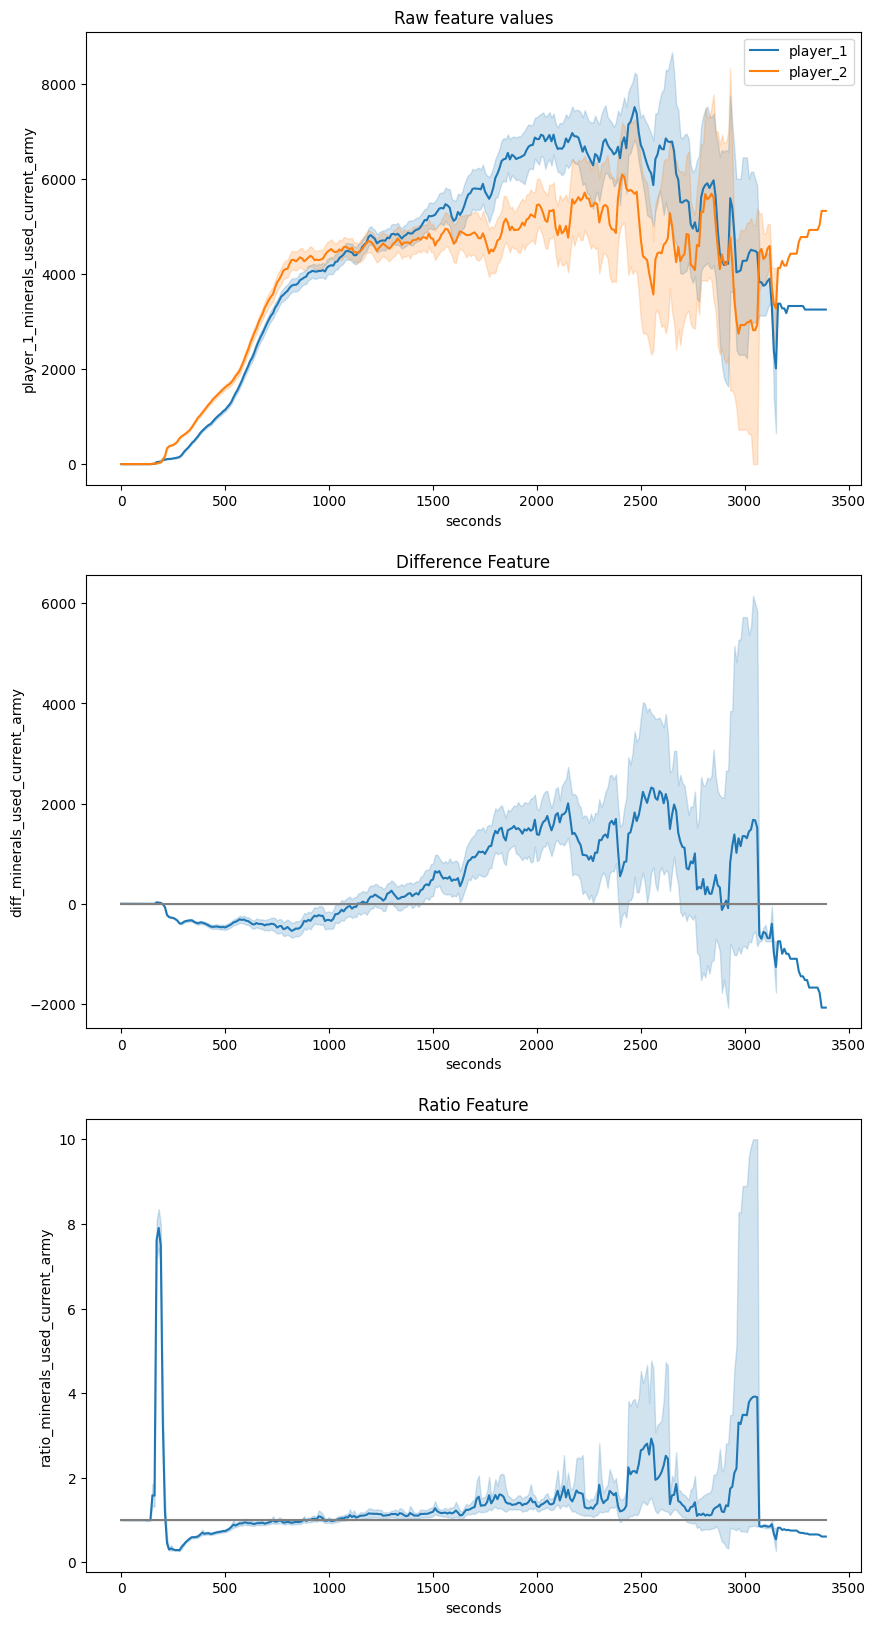

In [172]:
plot_feature(matchup_data, "minerals_used_current_army")

In [173]:
filehash = matchup_data["filehash"].unique()[0]

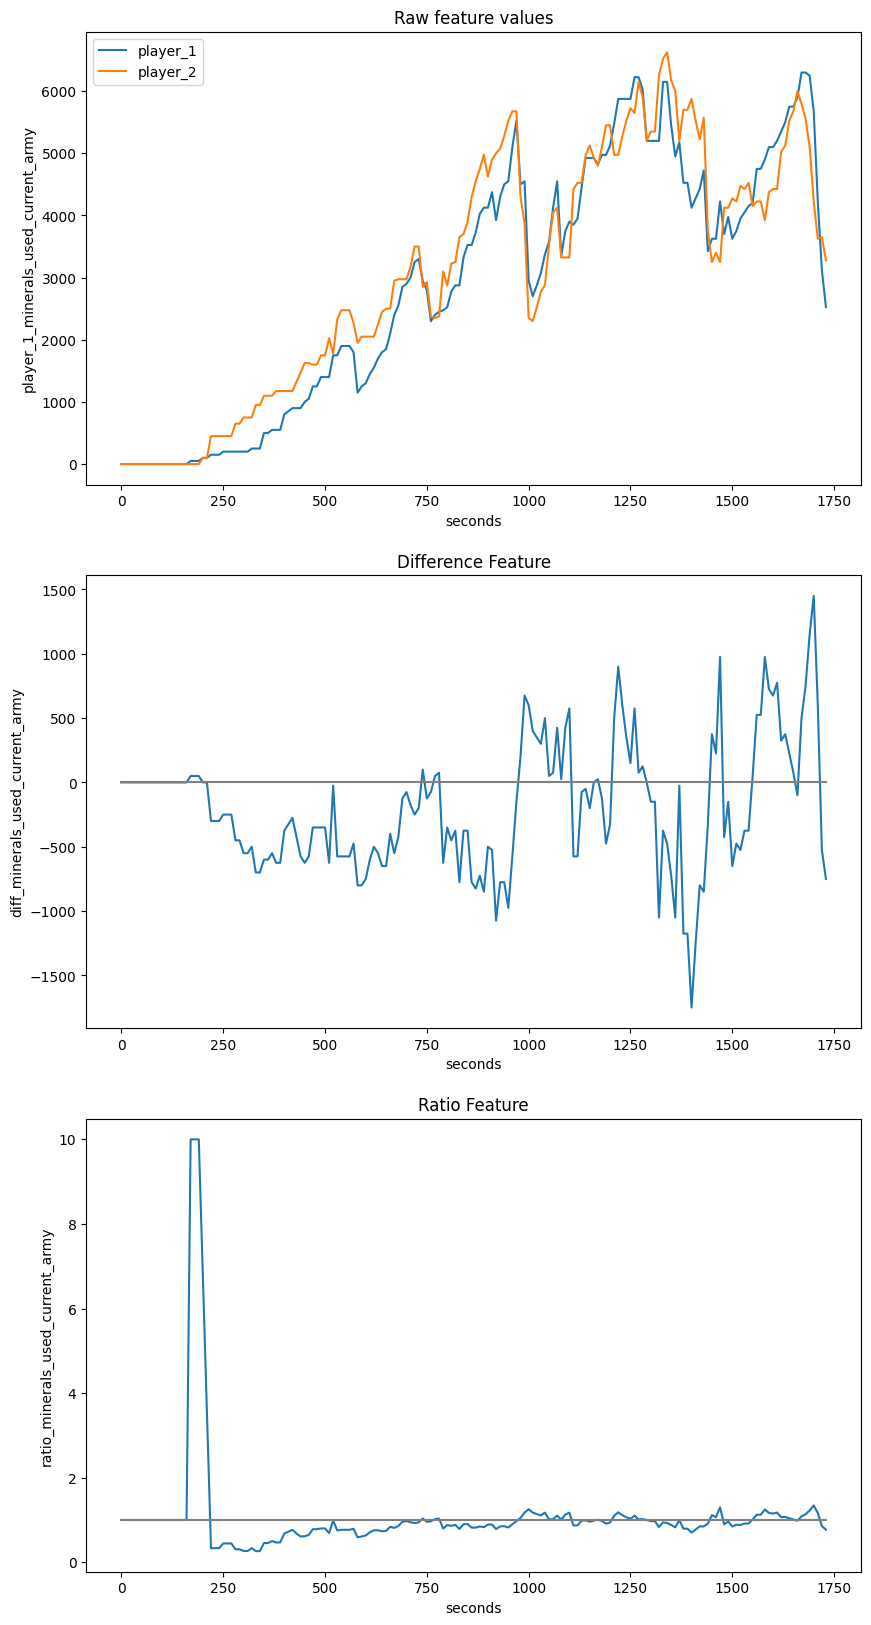

In [175]:
plot_feature(matchup_data, feature, filehash)